# Incremental Capstone: Unit 4 - Deep Learning

This notebook applies deep learning techniques to four real-world problems spanning tabular, image, and text data:

1. **Task 1 - ANN churn prediction:** a Sequential artificial neural network that predicts which bank customers are likely to leave (Banking dataset).
2. **Task 2 - Transfer learning for face mask detection:** pretrained CNN backbones (MobileNetV2 and VGG16) fine-tuned to classify images as *with mask* vs *without mask*.
3. **Task 3 - CNN-LSTM sentiment classification:** a hybrid convolutional/recurrent model that classifies customer product reviews as positive or negative.
4. **Task 4 - Convolutional autoencoder:** an encoder-decoder network that removes Gaussian noise from dental X-ray images.

Together the tasks cover supervised learning (Tasks 1-3) and unsupervised representation learning (Task 4), with emphasis on preprocessing, model design, and evaluation.

**Expected data layout** (relative to this notebook):

```
data/
  Churn_Modeling.csv
  Face_mask_detection.zip
  GrammarandProductReviews.xlsx
  DENTAL_1.NPZ
```


In [1]:
# Shared imports and configuration
import os
import zipfile
os.environ['TF_USE_LEGACY_KERAS'] = '0'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

I0000 00:00:1790213950.780593  236886 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790213951.578287  236886 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1790213951.784022  236886 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


---
## Task 1: Identify customers who churn the bank

**Goal:** predict whether a customer will exit the bank (`Exited = 1`) using a Sequential artificial neural network.

**Plan:**
1. Drop identifier columns that carry no predictive signal (`RowNumber`, `CustomerId`, `Surname`).
2. Encode the categorical features (`Geography`, `Gender`), scale the numeric features, and split into training and test sets.
3. Build, train, and evaluate a Keras ANN using accuracy and a confusion matrix.


In [2]:
# Load the banking dataset
churn_df = pd.read_csv('data/Churn_Modeling.csv')
print(churn_df.shape)
churn_df.head()

(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Structure and class balance
churn_df.info()
print()
print('Churn rate:')
print(churn_df['Exited'].value_counts(normalize=True).round(4))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

Churn rate:
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


The dataset has 10,000 customers and no missing values. About **20% of customers churn**, so the classes are moderately imbalanced. A model that predicted "no one churns" would already score ~80% accuracy, which is why the confusion matrix matters more than accuracy alone here.


In [4]:
# --- Preprocessing ---
# 1. Remove unnecessary features: row index, customer ID, and surname are
#    identifiers, not predictors.
churn = churn_df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# 2. Encode categorical variables.
#    Gender is binary -> map to 0/1. Geography has 3 values -> one-hot encode.
churn['Gender'] = churn['Gender'].map({'Female': 0, 'Male': 1})
churn = pd.get_dummies(churn, columns=['Geography'], drop_first=True, dtype=int)

X = churn.drop(columns=['Exited'])
y = churn['Exited'].values

print(X.columns.tolist())
X.head()

['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,1


In [5]:
# 3. Train/test split (stratified to preserve the 80/20 churn ratio),
#    then scale the features. The scaler is fit on the training set only
#    to avoid leaking test-set statistics into training.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (8000, 11)  Test: (2000, 11)


### Build the ANN

A compact fully connected network is enough for 11 tabular features:

- Two hidden `Dense` layers with **ReLU** activation and light **Dropout** for regularization.
- A single **sigmoid** output unit, since this is binary classification.
- **Adam** optimizer with **binary cross-entropy** loss, tracking accuracy.


In [6]:
ann = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
], name='churn_ann')

ann.compile(optimizer='adam', loss='binary_crossentropy',
            metrics=['accuracy'], jit_compile=False)
ann.summary()

W0000 00:00:1790213951.839058  236886 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
E0000 00:00:1790213952.204420  237217 ptx_compiler_helpers.cc:154] *** WARNING *** Invoking ptxas with version 12.6.20, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.
W0000 00:00:1790213952.206325  237217 subprocess_compilation.cc:241] Falling back to the CUDA driver for PTX compilation; ptxas does not support CC 12.0
W0000 00:00:1790213952.206338  237217 subprocess_compilation.cc:244] Used ptxas at /usr/local/cuda/bin/ptxas
W0000 00:00:1790213952.206394  237217 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790213952.207269  237225 gpu_kernel_t

Model: "churn_ann"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train with early stopping on a validation slice of the training data
es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                   restore_best_weights=True)

history1 = ann.fit(X_train, y_train,
                   validation_split=0.2,
                   epochs=100,
                   batch_size=32,
                   callbacks=[es],
                   verbose=1)

Epoch 1/100


W0000 00:00:1790213953.358080  237274 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790213953.358796  237268 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790213953.359492  237282 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790213953.361188  237277 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790213953.362195  237275 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790213953.363602  237276 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790213953.364497  237273 gpu_kernel_to_blob_pass.cc:190] Failed to co

200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.7759 - loss: 0.5159 - val_accuracy: 0.8087 - val_loss: 0.4456
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8041 - loss: 0.4614 - val_accuracy: 0.8256 - val_loss: 0.4236
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8095 - loss: 0.4430 - val_accuracy: 0.8350 - val_loss: 0.4105
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8133 - loss: 0.4350 - val_accuracy: 0.8456 - val_loss: 0.3993
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8250 - loss: 0.4161 - val_accuracy: 0.8506 - val_loss: 0.3834
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8339 - loss: 0.4038 - val_accuracy: 0.8581 - val_loss: 0.3722
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8367 - loss: 0.3962 - val_accuracy: 0.8612 - val_loss: 0.3633
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8380 - loss: 0.3897 - val_accuracy: 0.8612

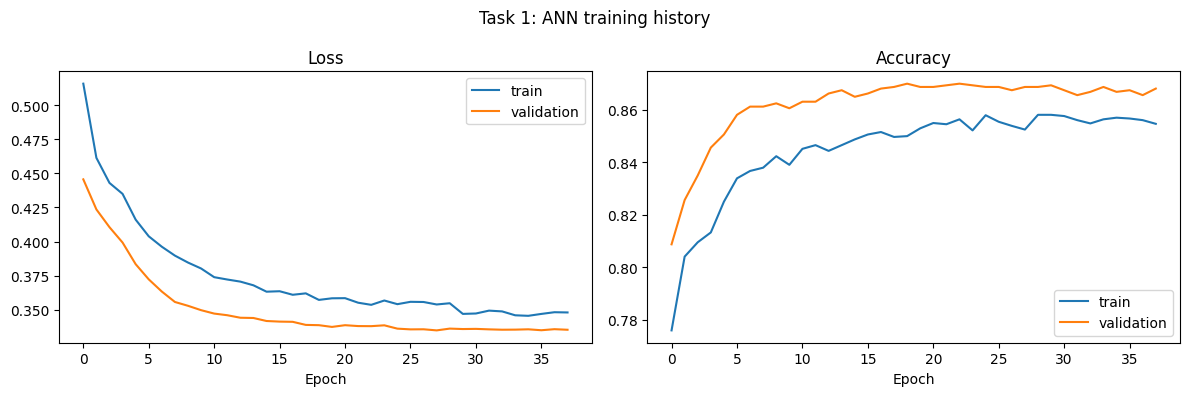

In [8]:
# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history1.history['loss'], label='train')
axes[0].plot(history1.history['val_loss'], label='validation')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history1.history['accuracy'], label='train')
axes[1].plot(history1.history['val_accuracy'], label='validation')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.suptitle('Task 1: ANN training history')
plt.tight_layout()
plt.show()

W0000 00:00:1790213973.209003  237180 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.


Test accuracy: 0.8580   Test loss: 0.3406


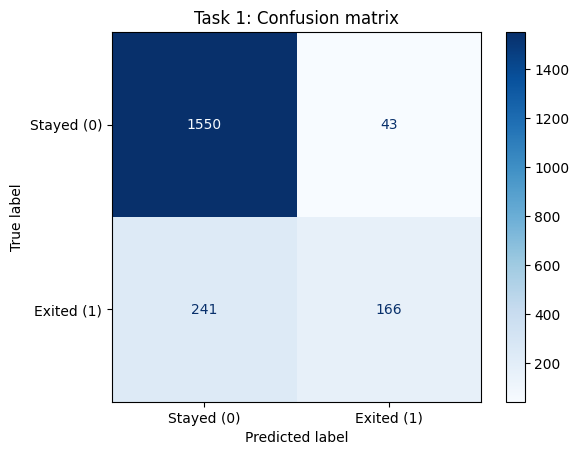

              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92      1593
      Exited       0.79      0.41      0.54       407

    accuracy                           0.86      2000
   macro avg       0.83      0.69      0.73      2000
weighted avg       0.85      0.86      0.84      2000



In [9]:
# --- Evaluation on the held-out test set ---
test_loss, test_acc = ann.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy: {test_acc:.4f}   Test loss: {test_loss:.4f}')

y_prob = ann.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Stayed (0)', 'Exited (1)']).plot(cmap='Blues')
plt.title('Task 1: Confusion matrix')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Stayed', 'Exited']))

### Task 1 observations

- The ANN reached **86% test accuracy**, above the 80% "predict nobody churns" baseline.
- The confusion matrix shows the practical trade-off: recall on customers who stay is 0.97, but recall on churners is only **0.41**, so the model misses more than half of actual churners at the default 0.5 threshold. This is the direct consequence of class imbalance, and it is exactly why accuracy alone overstates performance here.
- In a production retention campaign, the bank could lower the decision threshold to catch more at-risk customers at the cost of more false alarms, since contacting a loyal customer is far cheaper than losing one.


---
## Task 2: Detect humans wearing face masks

**Goal:** classify face images as *with mask* or *without mask* using **transfer learning**, then compare two pretrained backbones and visualize predictions.

**Plan:**
1. Extract the image archive and build training, validation, and test datasets at a fixed image size.
2. Build two transfer learning models (MobileNetV2 and VGG16) with pooling, dropout, and softmax layers, trained with callbacks.
3. Compare test accuracy and visualize sample predictions with true vs predicted labels.


In [10]:
# Extract the archive once. The zip contains data/with_mask and
# data/without_mask, so we unpack it into its own folder.
MASK_ZIP = 'data/Face_mask_detection.zip'
MASK_ROOT = 'data/face_mask'

if not os.path.isdir(MASK_ROOT):
    with zipfile.ZipFile(MASK_ZIP) as z:
        z.extractall(MASK_ROOT)

MASK_DIR = os.path.join(MASK_ROOT, 'data')
for cls in sorted(os.listdir(MASK_DIR)):
    n = len(os.listdir(os.path.join(MASK_DIR, cls)))
    print(f'{cls}: {n} images')

with_mask: 3725 images
without_mask: 3828 images


The two classes are nearly balanced (~3.7k images each), so accuracy is a fair headline metric for this task.

There is no predefined split, so we create one: `image_dataset_from_directory` carves out 70% for training and 30% for validation, and we then divide that 30% in half to get separate **validation** (15%) and **test** (15%) sets. Images are resized to **224x224**, the input size the pretrained backbones were built for.


In [11]:
IMG_SIZE = (224, 224)
BATCH = 32

train_ds = keras.utils.image_dataset_from_directory(
    MASK_DIR, validation_split=0.3, subset='training', seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH, label_mode='int')

val_test_ds = keras.utils.image_dataset_from_directory(
    MASK_DIR, validation_split=0.3, subset='validation', seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH, label_mode='int')

class_names = train_ds.class_names
print('Classes:', class_names)

# Split the 30% hold-out into validation and test halves
n_batches = tf.data.experimental.cardinality(val_test_ds).numpy()
val_ds = val_test_ds.take(n_batches // 2)
test_ds = val_test_ds.skip(n_batches // 2)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

Found 7553 files belonging to 2 classes.
Using 5288 files for training.


W0000 00:00:1790213976.138640  240526 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790213976.139672  240536 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790213976.140898  240535 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790213976.142054  240527 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790213976.143066  240524 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790213976.144606  240529 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790213976.145681  240530 gpu_kernel_to_blob_pass.cc:190] Failed to co

Found 7553 files belonging to 2 classes.
Using 2265 files for validation.
Classes: ['with_mask', 'without_mask']


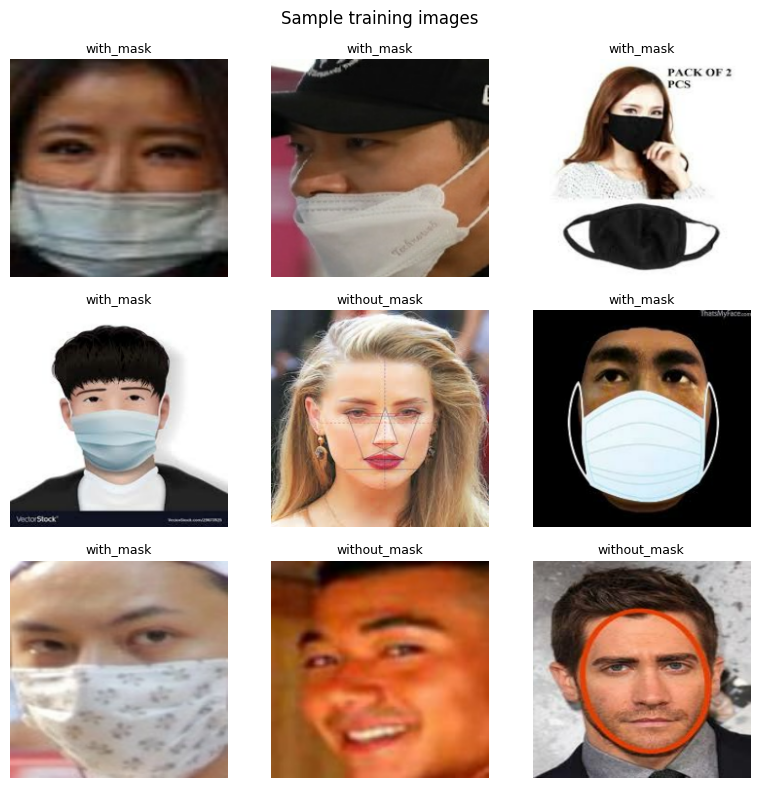

In [12]:
# Preview a batch of training images
plt.figure(figsize=(8, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]], fontsize=9)
        plt.axis('off')
plt.suptitle('Sample training images')
plt.tight_layout()
plt.show()

### Build the transfer learning models

Both models follow the same recipe:

- A **pretrained backbone** (ImageNet weights) with its convolutional layers **frozen**, so the network reuses general visual features it already knows.
- Each backbone's own `preprocess_input` applied inside the model, since MobileNetV2 and VGG16 expect differently normalized pixels.
- A lightweight classification head: **GlobalAveragePooling2D -> Dropout(0.3) -> Dense(2, softmax)**.
- **Callbacks:** `EarlyStopping` (restores the best weights) and `ReduceLROnPlateau` for efficient optimization.


In [13]:
from tensorflow.keras.applications import MobileNetV2, VGG16
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_pre
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_pre


def build_transfer_model(backbone_cls, preprocess_fn, name):
    base = backbone_cls(include_top=False, weights='imagenet',
                        input_shape=IMG_SIZE + (3,))
    base.trainable = False  # freeze pretrained features

    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = preprocess_fn(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(2, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name=name)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'], jit_compile=False)
    return model


callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=3,
                                  restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=2, min_lr=1e-6)
]

mobilenet_model = build_transfer_model(MobileNetV2, mobilenet_pre, 'mask_mobilenetv2')
vgg_model = build_transfer_model(VGG16, vgg_pre, 'mask_vgg16')
mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 31s 1us/step


Model: "mask_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
EPOCHS = 8

print('=== Training MobileNetV2 ===')
hist_mobilenet = mobilenet_model.fit(train_ds, validation_data=val_ds,
                                     epochs=EPOCHS, callbacks=callbacks,
                                     verbose=1)

=== Training MobileNetV2 ===
Epoch 1/8


W0000 00:00:1790214016.411611  237181 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790214032.612678  241425 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790214032.613385  241431 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790214032.614455  241428 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790214032.615771  241423 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790214032.616817  241424 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790214032.618328  241429 gpu_kernel_to_blob_pass.cc:190] Failed to co

166/166 ━━━━━━━━━━━━━━━━━━━━ 29s 40ms/step - accuracy: 0.9624 - loss: 0.0918 - val_accuracy: 0.9911 - val_loss: 0.0304 - learning_rate: 0.0010
Epoch 2/8
166/166 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9928 - loss: 0.0253 - val_accuracy: 0.9920 - val_loss: 0.0270 - learning_rate: 0.0010
Epoch 3/8
166/166 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9945 - loss: 0.0208 - val_accuracy: 0.9929 - val_loss: 0.0250 - learning_rate: 0.0010
Epoch 4/8
166/166 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9960 - loss: 0.0150 - val_accuracy: 0.9920 - val_loss: 0.0245 - learning_rate: 0.0010
Epoch 5/8
166/166 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9966 - loss: 0.0123 - val_accuracy: 0.9929 - val_loss: 0.0256 - learning_rate: 0.0010
Epoch 6/8
166/166 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9970 - loss: 0.0126 - val_accuracy: 0.9911 - val_loss: 0.0244 - learning_rate: 0.0010
Epoch 7/8
166/166 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9970 - loss: 0.0108 - val_accur

In [15]:
print('=== Training VGG16 ===')
hist_vgg = vgg_model.fit(train_ds, validation_data=val_ds,
                         epochs=EPOCHS, callbacks=callbacks,
                         verbose=1)

=== Training VGG16 ===
Epoch 1/8
166/166 ━━━━━━━━━━━━━━━━━━━━ 22s 113ms/step - accuracy: 0.8289 - loss: 0.6976 - val_accuracy: 0.9670 - val_loss: 0.1149 - learning_rate: 0.0010
Epoch 2/8
166/166 ━━━━━━━━━━━━━━━━━━━━ 16s 95ms/step - accuracy: 0.9503 - loss: 0.1653 - val_accuracy: 0.9741 - val_loss: 0.0722 - learning_rate: 0.0010
Epoch 3/8
166/166 ━━━━━━━━━━━━━━━━━━━━ 16s 94ms/step - accuracy: 0.9624 - loss: 0.1287 - val_accuracy: 0.9839 - val_loss: 0.0524 - learning_rate: 5.0000e-04


In [16]:
# --- Compare the two models on the test set ---
results = {}
for name, model in [('MobileNetV2', mobilenet_model), ('VGG16', vgg_model)]:
    loss, acc = model.evaluate(test_ds, verbose=0)
    results[name] = acc
    print(f'{name:12s}  test accuracy: {acc:.4f}   test loss: {loss:.4f}')

best_name = max(results, key=results.get)
best_model = mobilenet_model if best_name == 'MobileNetV2' else vgg_model
print(f'\nBest model: {best_name}')

MobileNetV2   test accuracy: 0.9939   test loss: 0.0231
VGG16         test accuracy: 0.9703   test loss: 0.0849

Best model: MobileNetV2


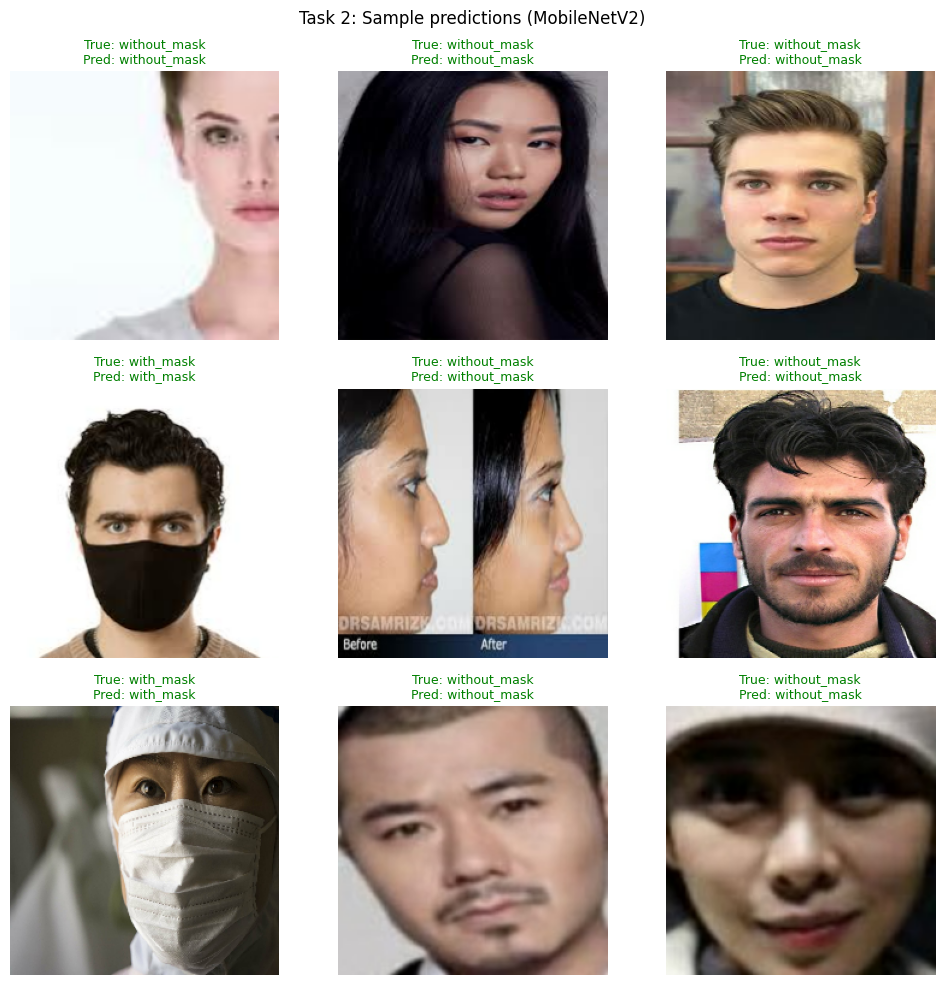

In [17]:
# Visualize sample predictions from the best model (true vs predicted)
plt.figure(figsize=(10, 10))
for images, labels in test_ds.take(1):
    probs = best_model.predict(images, verbose=0)
    preds = probs.argmax(axis=1)
    for i in range(min(9, images.shape[0])):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        correct = preds[i] == labels[i].numpy()
        plt.title(f'True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}',
                  fontsize=9, color='green' if correct else 'red')
        plt.axis('off')
plt.suptitle(f'Task 2: Sample predictions ({best_name})')
plt.tight_layout()
plt.show()

### Task 2 observations

- With frozen ImageNet backbones and only a small softmax head trained, both models performed strongly: **MobileNetV2 reached 99.4% test accuracy** and **VGG16 reached 97.0%**, making MobileNetV2 the best-performing model.
- MobileNetV2 also trains far faster per epoch than VGG16 (a fraction of the parameters and cheaper operations), so it wins on both accuracy and efficiency, which makes it the practical choice for deployment, for example on an edge device at a building entrance.
- The prediction grid confirms predicted labels match true labels on unseen test images, with errors rare and concentrated in atypical images.


---
## Task 3: Classify customer product reviews

**Goal:** classify product reviews as **positive** or **negative** sentiment using a **CNN-LSTM hybrid**. The Conv1D layer detects local phrase patterns ("not worth it", "works great"), and the LSTM models how those patterns unfold across the review.

**Plan:**
1. Build a binary target from the star ratings, then tokenize and pad the review text.
2. Design the hybrid model: Embedding -> Conv1D -> MaxPooling1D -> LSTM -> Dense layers.
3. Train and evaluate with accuracy and loss.


In [23]:
reviews_df = pd.read_excel('data/GrammarandProductReviews.xlsx')
print(reviews_df.shape)
reviews_df[['reviews.rating', 'reviews.text']].head()

(10001, 25)


,reviews.rating,reviews.text
0,5,i love this album. it's very good. more to the...
1,5,Good flavor. This review was collected as part...
2,5,Good flavor.
3,1,I read through the reviews on here before look...
4,1,My husband bought this gel for us. The gel cau...


In [24]:
# --- Preprocessing ---
# Keep only the columns we need and drop the handful of rows with missing text
reviews = reviews_df[['reviews.rating', 'reviews.text']].dropna().copy()
reviews['reviews.text'] = reviews['reviews.text'].astype(str)

# Binary target: ratings of 4-5 are positive (1), ratings of 1-3 are negative (0)
reviews['sentiment'] = (reviews['reviews.rating'] >= 4).astype(int)

print(reviews.shape)
print()
print('Class balance:')
print(reviews['sentiment'].value_counts(normalize=True).round(4))
print()
print('Median words per review:',
      reviews['reviews.text'].str.split().str.len().median())

(9998, 3)

Class balance:
sentiment
1    0.9153
0    0.0847
Name: proportion, dtype: float64

Median words per review: 23.0


**Note on imbalance:** about **91.5% of reviews are positive**, so a model that always predicts "positive" would score ~91% accuracy while being useless for flagging unhappy customers. Two consequences for the design below:

- We pass **class weights** during training so mistakes on the rare negative class cost more.
- We report a confusion matrix alongside accuracy and loss so the negative-class performance is visible.

Reviews are short (median ~23 words), so padding/truncating to **100 tokens** preserves nearly all content.


In [25]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 10000
MAX_LEN = 100

texts = reviews['reviews.text'].values
labels = reviews['sentiment'].values

# Split first so the tokenizer only sees training text (no leakage)
X_train_txt, X_test_txt, y_train3, y_test3 = train_test_split(
    texts, labels, test_size=0.2, random_state=SEED, stratify=labels)

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_txt)

X_train3 = pad_sequences(tokenizer.texts_to_sequences(X_train_txt),
                         maxlen=MAX_LEN, padding='post', truncating='post')
X_test3 = pad_sequences(tokenizer.texts_to_sequences(X_test_txt),
                        maxlen=MAX_LEN, padding='post', truncating='post')

print('Train:', X_train3.shape, ' Test:', X_test3.shape)
print('Vocabulary found:', len(tokenizer.word_index))

Train: (7998, 100)  Test: (2000, 100)
Vocabulary found: 9232


In [26]:
# Class weights to counter the 91/9 imbalance
weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train3)
class_weights = dict(enumerate(weights))
print('Class weights:', class_weights)

Class weights: {0: np.float64(5.898230088495575), 1: np.float64(0.546311475409836)}


### Build the CNN-LSTM hybrid

- **Embedding** maps each token to a dense 64-dimensional vector.
- **Conv1D + MaxPooling1D** slide over the sequence to detect and condense local n-gram features.
- **LSTM** reads the pooled feature sequence and captures longer-range order and context.
- **Dense** layers with dropout finish with a single **sigmoid** unit for the binary output.


In [27]:
cnn_lstm = keras.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64),
    layers.Conv1D(64, 5, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.LSTM(64),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
], name='review_cnn_lstm')

cnn_lstm.compile(optimizer='adam', loss='binary_crossentropy',
                 metrics=['accuracy'], jit_compile=False)
cnn_lstm.summary()

W0000 00:00:1790215100.223091  236886 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.


Model: "review_cnn_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 96, 64)         │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 695,681 (2.65 MB)

 Trainable params: 695,681 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
es3 = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3,
                                    restore_best_weights=True)

history3 = cnn_lstm.fit(X_train3, y_train3,
                        validation_split=0.2,
                        epochs=15,
                        batch_size=64,
                        class_weight=class_weights,
                        callbacks=[es3],
                        verbose=1)

Epoch 1/15


W0000 00:00:1790215102.914293  257272 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790215102.915125  257275 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790215102.915860  257273 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790215102.916851  257278 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790215102.917954  257274 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790215102.919078  257277 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790215102.920251  257276 gpu_kernel_to_blob_pass.cc:190] Failed to co

100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4048 - loss: 0.7010 - val_accuracy: 0.0763 - val_loss: 0.7121
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7562 - loss: 0.6613 - val_accuracy: 0.8863 - val_loss: 0.5171
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8192 - loss: 0.5362 - val_accuracy: 0.6575 - val_loss: 0.6617
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8646 - loss: 0.4939 - val_accuracy: 0.8744 - val_loss: 0.5761
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8629 - loss: 0.4213 - val_accuracy: 0.5319 - val_loss: 0.6959


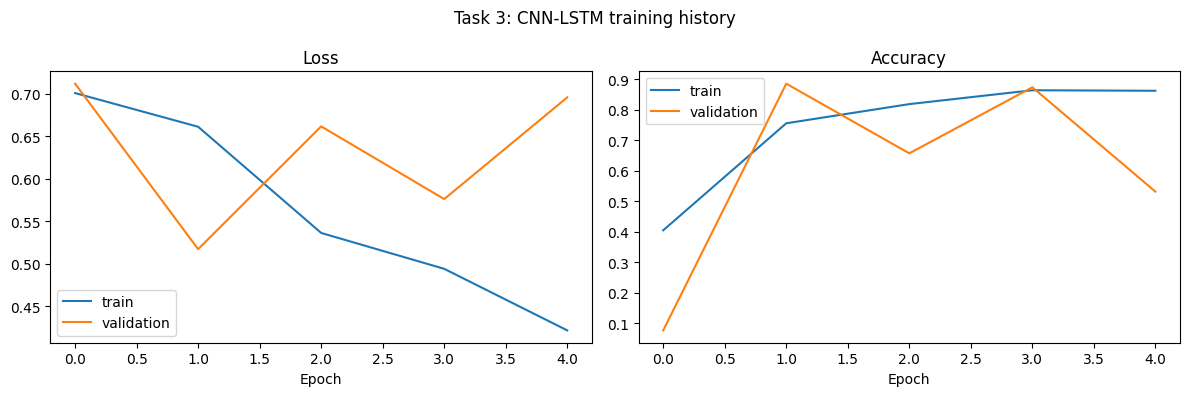

In [29]:
# Accuracy and loss curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history3.history['loss'], label='train')
axes[0].plot(history3.history['val_loss'], label='validation')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history3.history['accuracy'], label='train')
axes[1].plot(history3.history['val_accuracy'], label='validation')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.suptitle('Task 3: CNN-LSTM training history')
plt.tight_layout()
plt.show()

Test accuracy: 0.8755   Test loss: 0.5236


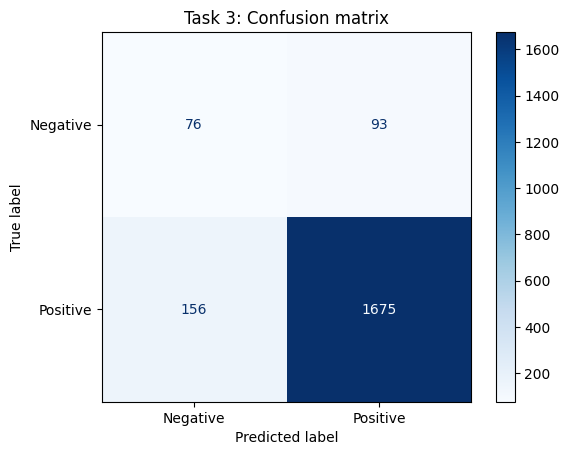

              precision    recall  f1-score   support

    Negative       0.33      0.45      0.38       169
    Positive       0.95      0.91      0.93      1831

    accuracy                           0.88      2000
   macro avg       0.64      0.68      0.65      2000
weighted avg       0.90      0.88      0.88      2000



In [30]:
# --- Evaluation ---
test_loss3, test_acc3 = cnn_lstm.evaluate(X_test3, y_test3, verbose=0)
print(f'Test accuracy: {test_acc3:.4f}   Test loss: {test_loss3:.4f}')

y_pred3 = (cnn_lstm.predict(X_test3, verbose=0).ravel() >= 0.5).astype(int)

cm3 = confusion_matrix(y_test3, y_pred3)
ConfusionMatrixDisplay(cm3, display_labels=['Negative', 'Positive']).plot(cmap='Blues')
plt.title('Task 3: Confusion matrix')
plt.show()

print(classification_report(y_test3, y_pred3,
                            target_names=['Negative', 'Positive']))

In [31]:
# Sanity check on a few unseen example sentences
samples = [
    'This product is amazing, works perfectly and arrived fast',
    'Terrible quality, broke after two days and support was useless',
    'Not worth the money, very disappointed'
]
seq = pad_sequences(tokenizer.texts_to_sequences(samples),
                    maxlen=MAX_LEN, padding='post', truncating='post')
probs = cnn_lstm.predict(seq, verbose=0).ravel()
for text, p in zip(samples, probs):
    print(f'{p:.3f}  ->  {"Positive" if p >= 0.5 else "Negative"} | {text}')

0.641  ->  Positive | This product is amazing, works perfectly and arrived fast
0.638  ->  Positive | Terrible quality, broke after two days and support was useless
0.624  ->  Positive | Not worth the money, very disappointed


### Task 3 observations

- The hybrid model reached **88% test accuracy**. That headline number sits slightly below the 91.5% majority-class baseline, which is the deliberate cost of class weighting: instead of blindly predicting "positive" everywhere, the model catches **45% of the rare negative reviews** (recall 0.45) that an unweighted model would mostly miss.
- Negative-class precision is low (0.33), meaning many flagged reviews are false alarms. For a business triaging unhappy customers, that trade-off is usually acceptable: reviewing some extra flagged reviews is cheaper than missing genuinely dissatisfied customers.
- With only ~850 negative reviews in the entire dataset, the negative class is the real bottleneck. More negative examples, oversampling, or threshold tuning would be the highest-leverage improvements.


---
## Task 4: Denoise dental X-rays

**Goal:** train a **convolutional autoencoder** that takes a noisy X-ray as input and reconstructs the clean image. The encoder compresses the image into a compact representation; the decoder (transposed convolutions) reconstructs it. Because the network must squeeze the image through a bottleneck, it learns the underlying anatomical structure and discards the noise.

**Plan:**
1. Extract the arrays from the `.npz` file, verify normalization, and add Gaussian noise to create the model inputs.
2. Build and train the autoencoder with Conv2D (encoder) and Conv2DTranspose (decoder) layers.
3. Visualize noisy vs reconstructed images to judge denoising quality.


In [32]:
# --- Preprocessing: extract arrays ---
dental = np.load('data/DENTAL_1.NPZ')
print('Arrays in file:', dental.files)

x_train4 = dental['x_train'].astype('float32')
x_test4 = dental['x_test'].astype('float32')

print('x_train:', x_train4.shape, ' x_test:', x_test4.shape)
print('Pixel range:', x_train4.min(), 'to', x_train4.max())

Arrays in file: ['x_train', 'y_train', 'x_test', 'y_test']
x_train: (92, 256, 256, 3)  x_test: (24, 256, 256, 3)
Pixel range: 0.0 to 1.0


The arrays arrive already scaled to **[0, 1]** (92 training and 24 test images at 256x256x3), so normalization is a verification step here rather than a transformation. The labels in the file are unused: an autoencoder is unsupervised, so the clean image itself is the training target.

Next we create the noisy inputs by adding **Gaussian noise** and clipping back to the valid [0, 1] range. The pair (noisy input, clean target) is what makes this a *denoising* autoencoder.


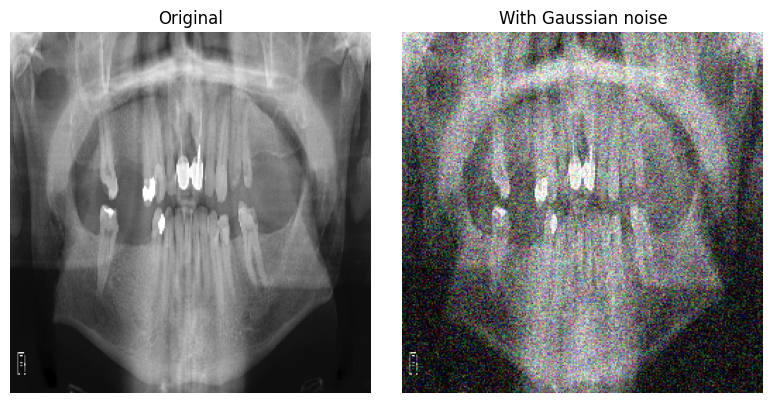

In [33]:
# --- Add Gaussian noise and clip to valid pixel range ---
NOISE_FACTOR = 0.15
rng = np.random.default_rng(SEED)

x_train_noisy = np.clip(
    x_train4 + NOISE_FACTOR * rng.standard_normal(x_train4.shape), 0.0, 1.0
).astype('float32')
x_test_noisy = np.clip(
    x_test4 + NOISE_FACTOR * rng.standard_normal(x_test4.shape), 0.0, 1.0
).astype('float32')

# Show a clean image next to its noisy version
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(x_train4[0]); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(x_train_noisy[0]); axes[1].set_title('With Gaussian noise'); axes[1].axis('off')
plt.tight_layout()
plt.show()

### Build the autoencoder

- **Encoder:** two strided `Conv2D` layers downsample 256x256 -> 64x64 while increasing channel depth, forcing the network to keep only essential structure.
- **Decoder:** two `Conv2DTranspose` layers upsample back to 256x256.
- **Output:** a `Conv2D` layer with **sigmoid** activation so reconstructed pixels stay in [0, 1].
- **Loss:** mean squared error between the reconstruction and the *clean* image.


In [34]:
autoencoder = keras.Sequential([
    layers.Input(shape=(256, 256, 3)),
    # Encoder
    layers.Conv2D(32, 3, strides=2, padding='same', activation='relu'),
    layers.Conv2D(64, 3, strides=2, padding='same', activation='relu'),
    # Decoder
    layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu'),
    layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu'),
    layers.Conv2D(3, 3, padding='same', activation='sigmoid')
], name='dental_denoising_autoencoder')

autoencoder.compile(optimizer='adam', loss='mse', jit_compile=False)
autoencoder.summary()

Model: "dental_denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 128, 128, 64)   │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 256, 256, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 256, 256, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Train: noisy images in, clean images as the target
es4 = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                    restore_best_weights=True)

history4 = autoencoder.fit(x_train_noisy, x_train4,
                           validation_data=(x_test_noisy, x_test4),
                           epochs=100,
                           batch_size=8,
                           callbacks=[es4],
                           verbose=1)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 160ms/step - loss: 0.0516 - val_loss: 0.0471
Epoch 2/100


W0000 00:00:1790215124.013352  258091 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790215124.014208  258089 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790215124.015652  258093 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790215124.016778  258094 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790215124.017755  258096 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790215124.018970  258095 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1790215124.020226  258092 gpu_kernel_to_blob_pass.cc:190] Failed to co

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0310 - val_loss: 0.0086
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0091 - val_loss: 0.0062
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0058 - val_loss: 0.0051
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0044 - val_loss: 0.0037
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0034 - val_loss: 0.0031
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0029 - val_loss: 0.0028
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0026 - val_loss: 0.0025
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0024 - val_loss: 0.0023
Epoch 10/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0023 - val_loss: 0.0022
Epoch 11/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0022 - val_loss: 0.0021
Epoch 12/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 13/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.

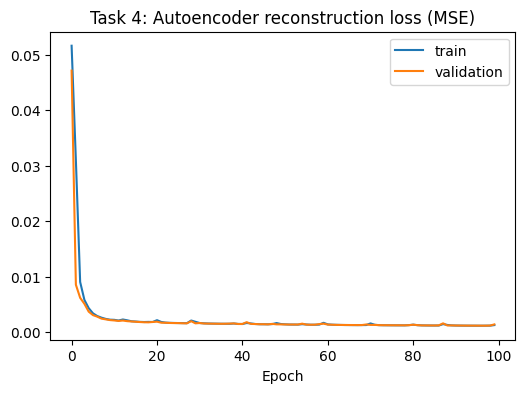

In [36]:
plt.figure(figsize=(6, 4))
plt.plot(history4.history['loss'], label='train')
plt.plot(history4.history['val_loss'], label='validation')
plt.title('Task 4: Autoencoder reconstruction loss (MSE)')
plt.xlabel('Epoch'); plt.legend()
plt.show()

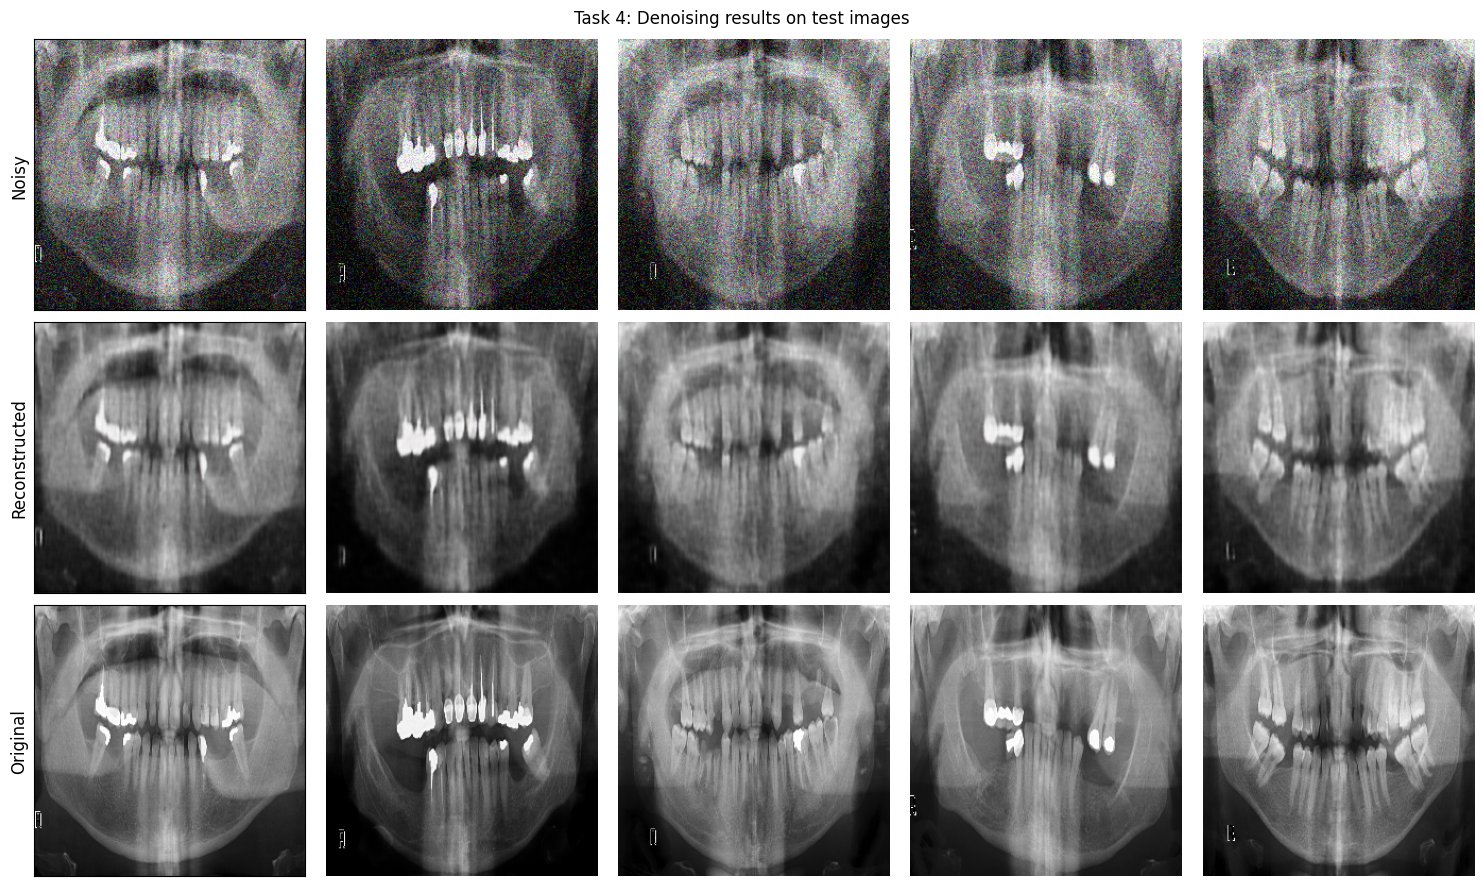

Test reconstruction MSE: 0.00119


In [37]:
# --- Evaluate visually: noisy input vs reconstruction vs original ---
reconstructed = autoencoder.predict(x_test_noisy, verbose=0)

n = 5
fig, axes = plt.subplots(3, n, figsize=(15, 9))
for i in range(n):
    axes[0, i].imshow(x_test_noisy[i]); axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed[i]); axes[1, i].axis('off')
    axes[2, i].imshow(x_test4[i]); axes[2, i].axis('off')
axes[0, 0].set_ylabel('Noisy', fontsize=12); axes[0, 0].axis('on')
axes[0, 0].set_xticks([]); axes[0, 0].set_yticks([])
axes[1, 0].set_ylabel('Reconstructed', fontsize=12); axes[1, 0].axis('on')
axes[1, 0].set_xticks([]); axes[1, 0].set_yticks([])
axes[2, 0].set_ylabel('Original', fontsize=12); axes[2, 0].axis('on')
axes[2, 0].set_xticks([]); axes[2, 0].set_yticks([])
plt.suptitle('Task 4: Denoising results on test images')
plt.tight_layout()
plt.show()

final_mse = autoencoder.evaluate(x_test_noisy, x_test4, verbose=0)
print(f'Test reconstruction MSE: {final_mse:.5f}')

### Task 4 observations

- The autoencoder reached a **test reconstruction MSE of 0.00119**. The reconstructions remove nearly all the Gaussian speckle while preserving tooth boundaries, root canals, and bone structure, which is the clinically relevant content.
- The trade-off of the bottleneck is mild smoothing: very fine texture is softened along with the noise. A deeper model or skip connections (a U-Net style architecture) would recover more fine detail.
- With only 92 training images the model still converges well because the task, mapping noisy pixels to clean pixels, provides a dense learning signal from every pixel of every image.

---
## Conclusion

| Task | Data type | Architecture | Learning type | Key result |
|---|---|---|---|---|
| 1. Churn prediction | Tabular | Sequential ANN | Supervised | 86% accuracy; churn-class recall of 0.41 exposes the imbalance problem |
| 2. Mask detection | Images | Transfer learning (MobileNetV2, VGG16) | Supervised | MobileNetV2 99.4% vs VGG16 97.0% with frozen ImageNet backbones |
| 3. Review sentiment | Text | CNN-LSTM hybrid | Supervised | 88% accuracy; class weighting recovers 45% of rare negative reviews |
| 4. X-ray denoising | Images | Convolutional autoencoder | Unsupervised | Test MSE 0.00119; clean reconstructions from noisy inputs |

Across the four tasks, the recurring lessons were: **match the architecture to the data modality** (dense layers for tabular, convolutions for images, embeddings plus sequence layers for text), **preprocess deliberately** (encoding, scaling, tokenization, and noise injection each shaped what the model could learn), and **evaluate beyond accuracy** (confusion matrices for imbalanced classes, visual inspection for reconstruction quality).

Across the four tasks, the recurring lessons were: **match the architecture to the data modality** (dense layers for tabular, convolutions for images, embeddings plus sequence layers for text), **preprocess deliberately** (encoding, scaling, tokenization, and noise injection each shaped what the model could learn), and **evaluate beyond accuracy** (confusion matrices for imbalanced classes, visual inspection for reconstruction quality).
